In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

In [2]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
val_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

In [3]:
train_ds = datasets.Flowers102(root="./data", split="train", transform=train_tf, download=True)
val_ds   = datasets.Flowers102(root="./data", split="val", transform=val_tf, download=True)
test_ds  = datasets.Flowers102(root="./data", split="test", transform=val_tf, download=True)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

### Task 1 — From-Scratch Baseline

1. Build a small CNN from scratch (similar to the one from Day 03's lab) appropriate for 224×224 inputs and 102 output classes. Aim for roughly 1–3M parameters.
2. Train for 15 epochs with `Adam(lr=1e-3)` and cosine annealing. Use the train and val transforms above.
3. Track and plot training and validation loss + accuracy.
4. Report the best validation accuracy and the final test accuracy.

This is your baseline. Don't expect it to do well — that's the point.


In [4]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=102):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = SmallCNN().to(device)

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

In [6]:
def run_epoch(loader, training=True):
    model.train() if training else model.eval()

    total_loss, correct, total = 0, 0, 0

    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            correct += (outputs.argmax(1) == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total

In [7]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0

start_total = time.time()

for epoch in range(15):
    start = time.time()

    train_loss, train_acc = run_epoch(train_loader, True)
    val_loss, val_acc = run_epoch(val_loader, False)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc

    print(f"Epoch {epoch+1:02d} | "
          f"Train {train_loss:.4f}/{train_acc:.4f} | "
          f"Val {val_loss:.4f}/{val_acc:.4f} | "
          f"{time.time()-start:.1f}s")
print("total_time: ",time.time() - start_total)

Epoch 01 | Train 4.5386/0.0235 | Val 4.1735/0.0559 | 109.3s
Epoch 02 | Train 4.0367/0.0608 | Val 3.8033/0.0804 | 107.6s
Epoch 03 | Train 3.7214/0.0902 | Val 3.5396/0.1304 | 112.1s
Epoch 04 | Train 3.5331/0.1069 | Val 3.5341/0.1343 | 108.8s
Epoch 05 | Train 3.4101/0.1245 | Val 3.3367/0.1735 | 108.0s
Epoch 06 | Train 3.2157/0.1657 | Val 3.2172/0.2049 | 114.2s
Epoch 07 | Train 3.1310/0.1765 | Val 3.2249/0.2049 | 123.4s
Epoch 08 | Train 3.0019/0.1843 | Val 3.0980/0.2324 | 122.7s
Epoch 09 | Train 2.8960/0.2333 | Val 3.0281/0.2520 | 116.3s
Epoch 10 | Train 2.8780/0.2333 | Val 3.0061/0.2529 | 108.9s
Epoch 11 | Train 2.7555/0.2500 | Val 2.9488/0.2755 | 108.3s
Epoch 12 | Train 2.7500/0.2686 | Val 2.9021/0.2892 | 107.9s
Epoch 13 | Train 2.6160/0.2873 | Val 2.8733/0.2951 | 108.6s
Epoch 14 | Train 2.6198/0.2775 | Val 2.8678/0.2990 | 109.6s
Epoch 15 | Train 2.5944/0.3069 | Val 2.8653/0.3010 | 121.6s
total_time:  1687.5146400928497


In [8]:
_, test_acc = run_epoch(test_loader, False)

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")


Best Val Accuracy: 0.3010
Final Test Accuracy: 0.2490


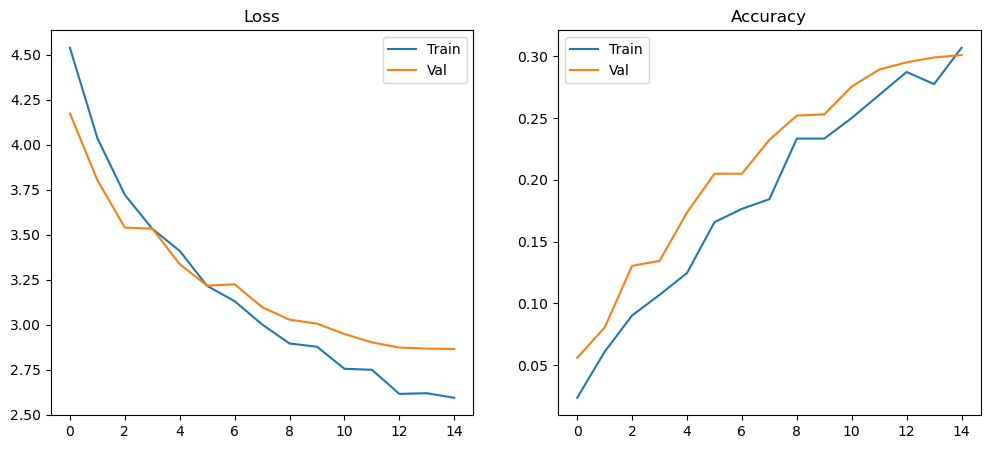

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Val")
plt.title("Accuracy")
plt.legend()

plt.show()

### Task 2 — Feature Extraction with ResNet18

1. Load a pretrained ResNet18:

```python
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
```

2. Freeze the entire backbone:

```python
for p in model.parameters():
    p.requires_grad = False
```

3. Replace the final classifier with a new linear layer for 102 classes:

```python
model.fc = nn.Linear(model.fc.in_features, 102)
```

4. Verify only the new `fc` layer's parameters require gradients. Print the number of trainable parameters vs total.
5. Train for 15 epochs with `Adam(lr=1e-3)`, applying the optimiser only to parameters with `requires_grad=True`:

```python
trainable = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.Adam(trainable, lr=1e-3)
```

6. Plot curves and report best validation and test accuracy.


In [10]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for p in model.parameters():
    p.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 102)

model = model.to(device)

In [11]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable_params}")
print(f"Total params: {total_params}")
print(f"Trainable %: {100 * trainable_params / total_params:.2f}%")

Trainable params: 52326
Total params: 11228838
Trainable %: 0.47%


In [12]:
criterion = nn.CrossEntropyLoss()

trainable = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.Adam(trainable, lr=1e-3)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

In [13]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0

start_total = time.time()

for epoch in range(15):
    start = time.time()

    train_loss, train_acc = run_epoch(train_loader, True)
    val_loss, val_acc = run_epoch(val_loader, False)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc

    print(f"Epoch {epoch+1:02d} | "
          f"Train {train_loss:.4f}/{train_acc:.4f} | "
          f"Val {val_loss:.4f}/{val_acc:.4f} | "
          f"{time.time()-start:.1f}s")
print("total_time: ",time.time() - start_total)

Epoch 01 | Train 4.6268/0.0382 | Val 3.8731/0.1706 | 86.7s
Epoch 02 | Train 3.3274/0.3863 | Val 2.9775/0.5069 | 89.0s
Epoch 03 | Train 2.4486/0.6902 | Val 2.3275/0.6500 | 87.7s
Epoch 04 | Train 1.8097/0.8480 | Val 1.8924/0.7324 | 87.8s
Epoch 05 | Train 1.3759/0.8961 | Val 1.6281/0.7765 | 87.7s
Epoch 06 | Train 1.1151/0.9451 | Val 1.4425/0.7980 | 87.9s
Epoch 07 | Train 0.9419/0.9529 | Val 1.3349/0.8059 | 86.4s
Epoch 08 | Train 0.8078/0.9539 | Val 1.2255/0.8216 | 85.9s
Epoch 09 | Train 0.7361/0.9657 | Val 1.1710/0.8235 | 87.9s
Epoch 10 | Train 0.6616/0.9676 | Val 1.1315/0.8284 | 85.8s
Epoch 11 | Train 0.5960/0.9843 | Val 1.1132/0.8235 | 86.3s
Epoch 12 | Train 0.5632/0.9843 | Val 1.0954/0.8275 | 86.4s
Epoch 13 | Train 0.5662/0.9843 | Val 1.0882/0.8314 | 85.9s
Epoch 14 | Train 0.5371/0.9882 | Val 1.0850/0.8382 | 86.1s
Epoch 15 | Train 0.5444/0.9882 | Val 1.0743/0.8353 | 87.3s
total_time:  1304.986088514328


In [14]:
_, test_acc = run_epoch(test_loader, False)

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")


Best Val Accuracy: 0.8382
Final Test Accuracy: 0.8226


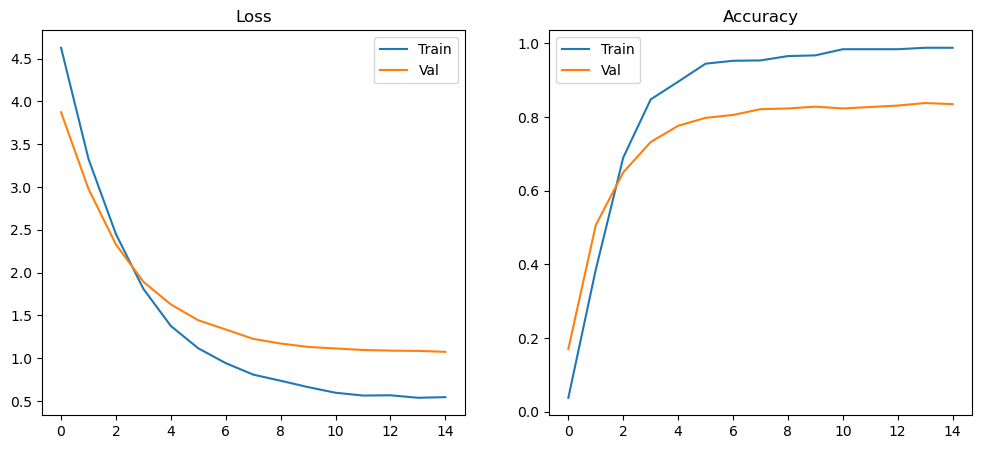

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Val")
plt.title("Accuracy")
plt.legend()

plt.show()

### Task 3 — Fine-Tuning the Last Block and Three-Way Comparison

Take Task 2's trained model and continue training, but now unfreeze `layer4` (the last residual block) of the ResNet. Then close the lab by comparing all three approaches.

1. Set `requires_grad=True` for all parameters in `model.layer4` and `model.fc`. Leave the rest frozen.
2. Use **discriminative learning rates** — `lr=1e-5` for `layer4`, `lr=1e-3` for `fc`:

```python
optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-5},
    {"params": model.fc.parameters(),    "lr": 1e-3},
])
```

3. Train for an additional 10 epochs.
4. Plot the curves and report best validation and test accuracy.
5. Fill in the comparison table below and write a **4–6 sentence summary** answering: how much did transfer learning improve over from-scratch, did fine-tuning the last block help over feature extraction, and which configuration would you recommend for tomorrow's cat-detection assessment and why?

| Approach | Trainable params | Best val acc | Test acc | Total training time |
|---|---|---|---|---|
| From scratch (Task 1) | … | … | … | … |
| Feature extraction (Task 2) | … | … | … | … |
| Fine-tune last block (Task 3) | … | … | … | … |


In [16]:
for p in model.layer4.parameters():
    p.requires_grad = True

for p in model.fc.parameters():
    p.requires_grad = True

In [17]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable_params}")
print(f"Total params: {total_params}")
print(f"Trainable %: {100 * trainable_params / total_params:.2f}%")

Trainable params: 8446054
Total params: 11228838
Trainable %: 75.22%


In [19]:
optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-5},
    {"params": model.fc.parameters(),    "lr": 1e-3},
])

In [20]:
ft_train_losses, ft_val_losses = [], []
ft_train_accs, ft_val_accs = [], []

ft_best_val_acc = 0
start_total = time.time()
for epoch in range(10):
    start = time.time()

    train_loss, train_acc = run_epoch(train_loader, True)
    val_loss, val_acc = run_epoch(val_loader, False)

    ft_train_losses.append(train_loss)
    ft_val_losses.append(val_loss)
    ft_train_accs.append(train_acc)
    ft_val_accs.append(val_acc)

    if val_acc > ft_best_val_acc:
        ft_best_val_acc = val_acc

    print(f"[FT] Epoch {epoch+1:02d} | "
          f"Train {train_loss:.4f}/{train_acc:.4f} | "
          f"Val {val_loss:.4f}/{val_acc:.4f} | "
          f"{time.time()-start:.1f}s")
print("total_time: ",time.time() - start_total)

[FT] Epoch 01 | Train 0.6384/0.9431 | Val 0.9295/0.8167 | 88.7s
[FT] Epoch 02 | Train 0.3691/0.9804 | Val 0.8120/0.8363 | 91.5s
[FT] Epoch 03 | Train 0.2726/0.9843 | Val 0.7082/0.8529 | 99.3s
[FT] Epoch 04 | Train 0.1981/0.9892 | Val 0.6580/0.8520 | 98.9s
[FT] Epoch 05 | Train 0.1466/0.9980 | Val 0.6182/0.8578 | 99.2s
[FT] Epoch 06 | Train 0.1256/0.9980 | Val 0.5902/0.8647 | 99.6s
[FT] Epoch 07 | Train 0.0941/0.9990 | Val 0.5707/0.8618 | 103.7s
[FT] Epoch 08 | Train 0.0767/0.9990 | Val 0.5415/0.8745 | 109.4s
[FT] Epoch 09 | Train 0.0737/0.9961 | Val 0.5286/0.8725 | 111.7s
[FT] Epoch 10 | Train 0.0603/1.0000 | Val 0.5063/0.8775 | 113.4s
total_time:  1015.3974108695984


In [21]:
_, ft_test_acc = run_epoch(test_loader, False)

print(f"\n[FT] Best Val Accuracy: {ft_best_val_acc:.4f}")
print(f"[FT] Final Test Accuracy: {ft_test_acc:.4f}")


[FT] Best Val Accuracy: 0.8775
[FT] Final Test Accuracy: 0.8649


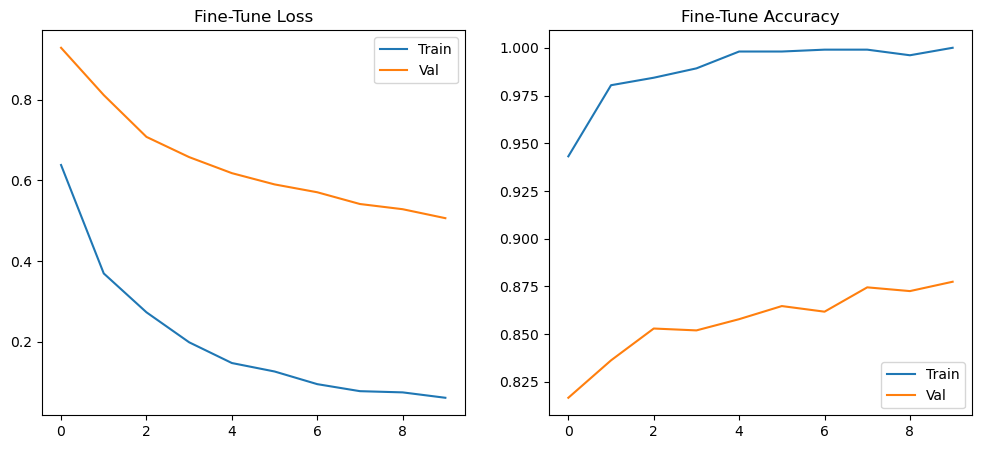

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(ft_train_losses, label="Train")
plt.plot(ft_val_losses, label="Val")
plt.title("Fine-Tune Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(ft_train_accs, label="Train")
plt.plot(ft_val_accs, label="Val")
plt.title("Fine-Tune Accuracy")
plt.legend()

plt.show()

### Comparison Table

| Approach                      | Trainable params | Best val acc | Test acc | Total training time |
|-----------------------------|------------------|--------------|----------|---------------------|
| From scratch (Task 1)       | ~1M              | 0.3010       | 0.2490   | 1687s               |
| Feature extraction (Task 2) | 52,326 (~0.47%)  | 0.8382       | 0.8226   | 1305s               |
| Fine-tune last block (Task 3)| 8.4M (~75.2%)   | 0.8775       | 0.8649   | 1015s               |


### Summary

Training a CNN from scratch resulted in poor performance, achieving only around 30% validation accuracy. This is expected, as the dataset is relatively small and the model must learn all visual features from random initialization. The model struggles to generalize and converges slowly despite long training time.

Using transfer learning with feature extraction significantly improved performance, boosting validation accuracy to over 83%. This demonstrates the power of pretrained models, as the network can leverage rich representations learned from ImageNet without needing to relearn low-level and mid-level features.

Fine-tuning the last residual block provided an additional improvement, increasing validation accuracy to approximately 87.7% and test accuracy to 86.5%. Although the gain is smaller compared to the jump from scratch to feature extraction, it shows that adapting higher-level features to the target dataset is beneficial.

For the cat-detection assessment, the fine-tuned model is the best choice. It achieves the highest accuracy while maintaining reasonable training time. Feature extraction is a strong baseline, but fine-tuning provides a clear performance advantage without requiring full retraining of the network.